In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats



In [2]:
data = pd.read_csv('data/MLR_Friendly_Shark_Tank_India.csv')
df = data.copy()
display(df.columns)

Index(['Agriculture', 'Animal/Pets', 'Beauty/Fashion', 'Business Services',
       'Children/Education', 'Electronics', 'Entertainment',
       'Fitness/Sports/Outdoors', 'Food And Beverage', 'Green/Cleantech',
       'Hardware', 'Lifestyle/Home', 'Liquor/Alcohol', 'Manufacturing',
       'Medical/Health', 'Others', 'Technology/Software',
       'Vehicles/Electrical Vehicles', 'Pitchers Average Age',
       'Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Original Ask Amount',
       'Original Offered Equity', 'Deal Valuation', 'Company Age'],
      dtype='object')

# model without dummy variable 

In [3]:
Y = df['Deal Valuation'] 
X_without_dummy = df[['Pitchers Average Age','Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Original Ask Amount',
       'Original Offered Equity', 'Company Age']]

X_train = X_without_dummy.astype(float)
Y_train = Y.astype(float)

# Add the constant (Intercept) to the training set
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(Y_train, X_train_sm).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Deal Valuation   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     74.67
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           8.33e-91
Time:                        15:30:41   Log-Likelihood:                -468.98
No. Observations:                 423   AIC:                             962.0
Df Residuals:                     411   BIC:                             1011.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       7.1095      0.074     95.997      0.000       6.964       7.255
Pitchers Average Age        0.0980      0.086      1.134      0.257      -0.072       0.268
Yearly Revenue              0.0545      0.044      1.251      0.212      -0.031       0.140
Gross Margin                0.0727      0.039      1.867      0.063      -0.004       0.149
Net Margin                 -0.0156      0.042     -0.370      0.712      -0.099       0.067
EBITDA                      0.0349      0.040      0.867      0.386      -0.044       0.114
Has Patents                 0.1755      0.134      1.314      0.190      -0.087       0.438
Bootstrapped               -0.1528      0.128     -1.190      0.235      -0.405       0.100
SKUs                        0.0378      0.042      0.902      0.368      -0.045       0.120
Original Ask Amount         0.5596      0.040     14.028      0.000       0.481       0.638
Original Offered Equity    -0.6650      0.040    -16.721      0.000      -0.743      -0.587
Company Age                 0.0116      0.042      0.276      0.782      -0.071       0.094
==============================================================================
Omnibus:                       32.175   Durbin-Watson:                   1.834
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              101.745
Skew:                          -0.261   Prob(JB):                     8.06e-23
Kurtosis:                       5.345   Cond. No.                         5.23
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

cheacking the effect on model after removing Original Offered Equity and Original Ask Amount 

In [4]:
Y = df['Deal Valuation'] 
X_without_dummy = df[['Pitchers Average Age','Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs',
       'Original Offered Equity', 'Company Age']]

X_train = X_without_dummy.astype(float)
Y_train = Y.astype(float)

# Add the constant (Intercept) to the training set
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(Y_train, X_train_sm).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Deal Valuation   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.495
Method:                 Least Squares   F-statistic:                     42.34
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           3.04e-57
Time:                        15:30:42   Log-Likelihood:                -551.73
No. Observations:                 423   AIC:                             1125.
Df Residuals:                     412   BIC:                             1170.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       6.9684      0.089     78.192      0.000       6.793       7.144
Pitchers Average Age        0.2835      0.104      2.732      0.007       0.080       0.487
Yearly Revenue              0.1378      0.052      2.629      0.009       0.035       0.241
Gross Margin                0.1034      0.047      2.190      0.029       0.011       0.196
Net Margin                 -0.0300      0.051     -0.585      0.559      -0.131       0.071
EBITDA                      0.0513      0.049      1.051      0.294      -0.045       0.147
Has Patents                 0.1035      0.162      0.638      0.524      -0.215       0.422
Bootstrapped               -0.0260      0.156     -0.167      0.867      -0.332       0.280
SKUs                        0.0311      0.051      0.611      0.542      -0.069       0.131
Original Offered Equity    -0.7903      0.047    -16.788      0.000      -0.883      -0.698
Company Age                 0.0552      0.051      1.083      0.279      -0.045       0.156
==============================================================================
Omnibus:                      135.580   Durbin-Watson:                   1.931
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1459.368
Skew:                          -1.036   Prob(JB):                         0.00
Kurtosis:                      11.860   Cond. No.                         5.09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [5]:
Y = df['Deal Valuation'] 
X_without_dummy = df[['Pitchers Average Age','Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Original Ask Amount',
        'Company Age']]

X_train = X_without_dummy.astype(float)
Y_train = Y.astype(float)

# Add the constant (Intercept) to the training set
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(Y_train, X_train_sm).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Deal Valuation   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     32.33
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           4.59e-46
Time:                        15:30:42   Log-Likelihood:                -578.74
No. Observations:                 423   AIC:                             1179.
Df Residuals:                     412   BIC:                             1224.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    6.8666      0.094     73.033      0.000       6.682       7.051
Pitchers Average Age     0.3975      0.109      3.631      0.000       0.182       0.613
Yearly Revenue           0.1700      0.056      3.053      0.002       0.061       0.279
Gross Margin             0.0487      0.050      0.967      0.334      -0.050       0.148
Net Margin              -0.0194      0.055     -0.354      0.724      -0.127       0.088
EBITDA                   0.0642      0.052      1.235      0.217      -0.038       0.166
Has Patents              0.3701      0.172      2.148      0.032       0.031       0.709
Bootstrapped            -0.0760      0.166     -0.458      0.647      -0.402       0.250
SKUs                     0.0562      0.054      1.035      0.301      -0.051       0.163
Original Ask Amount      0.7093      0.050     14.095      0.000       0.610       0.808
Company Age             -0.0255      0.054     -0.469      0.640      -0.133       0.082
==============================================================================
Omnibus:                        2.419   Durbin-Watson:                   1.784
Prob(Omnibus):                  0.298   Jarque-Bera (JB):                2.448
Skew:                          -0.052   Prob(JB):                        0.294
Kurtosis:                       3.358   Cond. No.                         5.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
Y = df['Deal Valuation'] 
X_new = df[['Pitchers Average Age','Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Company Age']]

X_train = X_new.astype(float)
Y_train = Y.astype(float)

# Add the constant (Intercept) to the training set
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(Y_train, X_train_sm).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Deal Valuation   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     9.363
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           5.48e-13
Time:                        15:30:42   Log-Likelihood:                -661.97
No. Observations:                 423   AIC:                             1344.
Df Residuals:                     413   BIC:                             1384.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    6.6171      0.112     58.933      0.000       6.396       6.838
Pitchers Average Age     0.7203      0.130      5.534      0.000       0.464       0.976
Yearly Revenue           0.3103      0.067      4.657      0.000       0.179       0.441
Gross Margin             0.0837      0.061      1.367      0.172      -0.037       0.204
Net Margin              -0.0395      0.067     -0.594      0.553      -0.170       0.091
EBITDA                   0.0935      0.063      1.480      0.140      -0.031       0.218
Has Patents              0.3229      0.209      1.542      0.124      -0.089       0.735
Bootstrapped             0.1125      0.201      0.559      0.577      -0.283       0.508
SKUs                     0.0519      0.066      0.786      0.432      -0.078       0.182
Company Age              0.0234      0.066      0.354      0.724      -0.106       0.153
==============================================================================
Omnibus:                       38.810   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               94.854
Skew:                          -0.461   Prob(JB):                     2.53e-21
Kurtosis:                       5.129   Cond. No.                         5.04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# we cant remove Original Ask Amount Original Offered Equity as then our model accuracy reduced

In [7]:
Y = df['Deal Valuation'] 
X_without_dummy = df[['Pitchers Average Age','Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Original Ask Amount',
       'Original Offered Equity', 'Company Age']]
 
X_train = X_without_dummy.astype(float)
Y_train = Y.astype(float)

# Add the constant (Intercept) to the training set
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(Y_train, X_train_sm).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Deal Valuation   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     74.67
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           8.33e-91
Time:                        15:30:42   Log-Likelihood:                -468.98
No. Observations:                 423   AIC:                             962.0
Df Residuals:                     411   BIC:                             1011.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       7.1095      0.074     95.997      0.000       6.964       7.255
Pitchers Average Age        0.0980      0.086      1.134      0.257      -0.072       0.268
Yearly Revenue              0.0545      0.044      1.251      0.212      -0.031       0.140
Gross Margin                0.0727      0.039      1.867      0.063      -0.004       0.149
Net Margin                 -0.0156      0.042     -0.370      0.712      -0.099       0.067
EBITDA                      0.0349      0.040      0.867      0.386      -0.044       0.114
Has Patents                 0.1755      0.134      1.314      0.190      -0.087       0.438
Bootstrapped               -0.1528      0.128     -1.190      0.235      -0.405       0.100
SKUs                        0.0378      0.042      0.902      0.368      -0.045       0.120
Original Ask Amount         0.5596      0.040     14.028      0.000       0.481       0.638
Original Offered Equity    -0.6650      0.040    -16.721      0.000      -0.743      -0.587
Company Age                 0.0116      0.042      0.276      0.782      -0.071       0.094
==============================================================================
Omnibus:                       32.175   Durbin-Watson:                   1.834
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              101.745
Skew:                          -0.261   Prob(JB):                     8.06e-23
Kurtosis:                       5.345   Cond. No.                         5.23
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

residual analysis

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


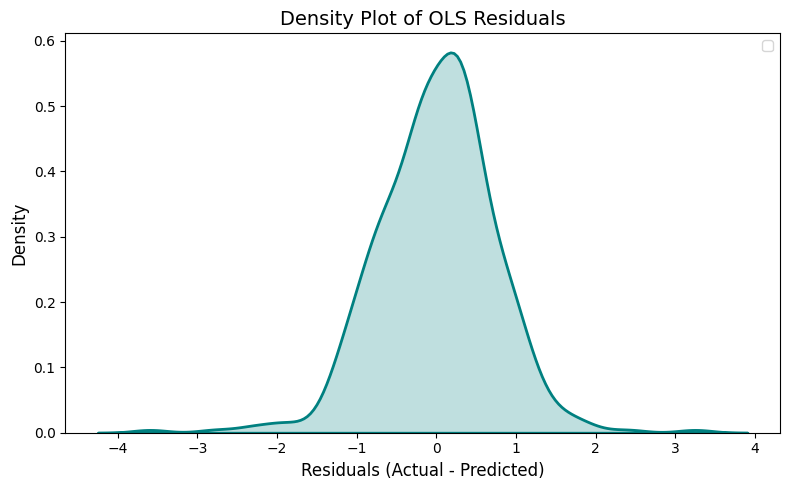

In [8]:
residuals = model.resid

plt.figure(figsize=(8, 5))

sns.kdeplot(
        data=df, 
        x=residuals, 
        fill=True, 
        color='teal', 
        linewidth=2
    )

# Labels and Title
plt.title('Density Plot of OLS Residuals', fontsize=14)
plt.xlabel('Residuals (Actual - Predicted)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

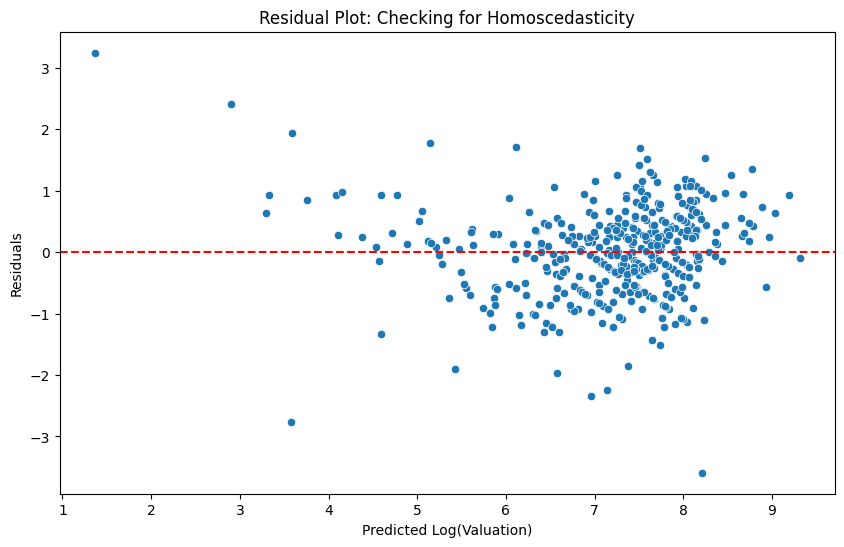

In [9]:

residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Log(Valuation)')
plt.ylabel('Residuals')
plt.title('Residual Plot: Checking for Homoscedasticity')
plt.show()


remove residual outliers

In [10]:
# Get the influence metrics from your fitted model
influence = model.get_influence()

# Use EXTERNALLY studentized residuals (The superior statistical method)
true_studentized_residuals = influence.resid_studentized_external

display(np.sort(np.abs(true_studentized_residuals)))

array([2.16804463e-03, 3.10837881e-03, 5.95290055e-03, 8.21699329e-03,
       1.13765449e-02, 1.13839967e-02, 1.43778781e-02, 1.52438565e-02,
       2.22238031e-02, 2.48101319e-02, 2.76678639e-02, 3.75380832e-02,
       3.77391798e-02, 4.08555972e-02, 4.98746783e-02, 5.05978713e-02,
       5.38761849e-02, 5.68730565e-02, 6.02356895e-02, 6.05316228e-02,
       6.96134323e-02, 7.23599012e-02, 7.34318333e-02, 7.42592451e-02,
       7.73136955e-02, 7.96767379e-02, 8.47255049e-02, 8.55655401e-02,
       9.74359782e-02, 9.93149719e-02, 1.04984855e-01, 1.07008248e-01,
       1.08118560e-01, 1.16138484e-01, 1.17237720e-01, 1.18691788e-01,
       1.20567523e-01, 1.22842996e-01, 1.23408359e-01, 1.29474349e-01,
       1.33198972e-01, 1.36797843e-01, 1.39162515e-01, 1.39748997e-01,
       1.42984593e-01, 1.46191957e-01, 1.46664816e-01, 1.55580756e-01,
       1.62296293e-01, 1.64859386e-01, 1.69340809e-01, 1.70399071e-01,
       1.70474744e-01, 1.71007690e-01, 1.71511601e-01, 1.76397677e-01,
      

In [11]:
# Create a mask for values greater than 2.5  because i find 10 outliers pointing to 2.5 as the threshold
outlier_mask = np.abs(true_studentized_residuals) > 2.5

# Find and drop those indices
outlier_indices = data.index[outlier_mask]

display(df.shape)
df = df.drop(index=outlier_indices).reset_index(drop=True)
display(df.shape)

(423, 30)

(412, 30)

new model aftrer removing outlier

In [12]:
Y = df['Deal Valuation'] 
X_without_dummy = df[['Pitchers Average Age','Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Original Ask Amount',
       'Original Offered Equity', 'Company Age']]

# Force data types to float to prevent the "object" error we discussed earlier
X_train = X_without_dummy.astype(float)
Y_train = Y.astype(float)

# Add the constant (Intercept) to the training set
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(Y_train, X_train_sm).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Deal Valuation   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     101.4
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          2.44e-108
Time:                        15:30:42   Log-Likelihood:                -382.63
No. Observations:                 412   AIC:                             789.3
Df Residuals:                     400   BIC:                             837.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       7.1709      0.064    112.764      0.000       7.046       7.296
Pitchers Average Age        0.0414      0.076      0.548      0.584      -0.107       0.190
Yearly Revenue              0.0284      0.038      0.758      0.449      -0.045       0.102
Gross Margin                0.0750      0.034      2.233      0.026       0.009       0.141
Net Margin                 -0.0080      0.036     -0.222      0.824      -0.078       0.062
EBITDA                      0.0445      0.034      1.312      0.190      -0.022       0.111
Has Patents                 0.1448      0.114      1.269      0.205      -0.080       0.369
Bootstrapped               -0.1823      0.107     -1.698      0.090      -0.393       0.029
SKUs                        0.0072      0.035      0.203      0.839      -0.063       0.077
Original Ask Amount         0.5063      0.040     12.543      0.000       0.427       0.586
Original Offered Equity    -0.8361      0.039    -21.251      0.000      -0.913      -0.759
Company Age                 0.0218      0.035      0.615      0.539      -0.048       0.092
==============================================================================
Omnibus:                        6.411   Durbin-Watson:                   1.908
Prob(Omnibus):                  0.041   Jarque-Bera (JB):                4.254
Skew:                          -0.077   Prob(JB):                        0.119
Kurtosis:                       2.526   Cond. No.                         5.24
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

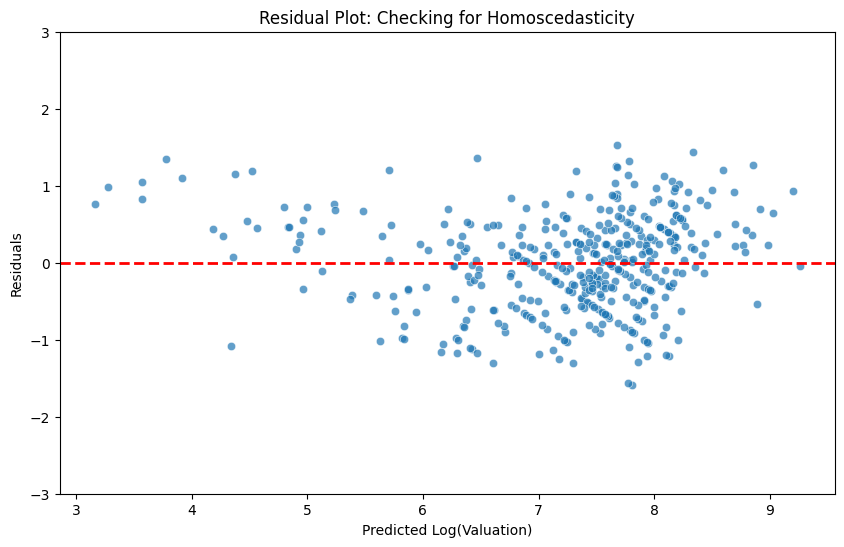

In [13]:
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Set the y-axis limits from -3 to 3
plt.ylim(-3, 3)

plt.xlabel('Predicted Log(Valuation)')
plt.ylabel('Residuals')
plt.title('Residual Plot: Checking for Homoscedasticity')
plt.show()

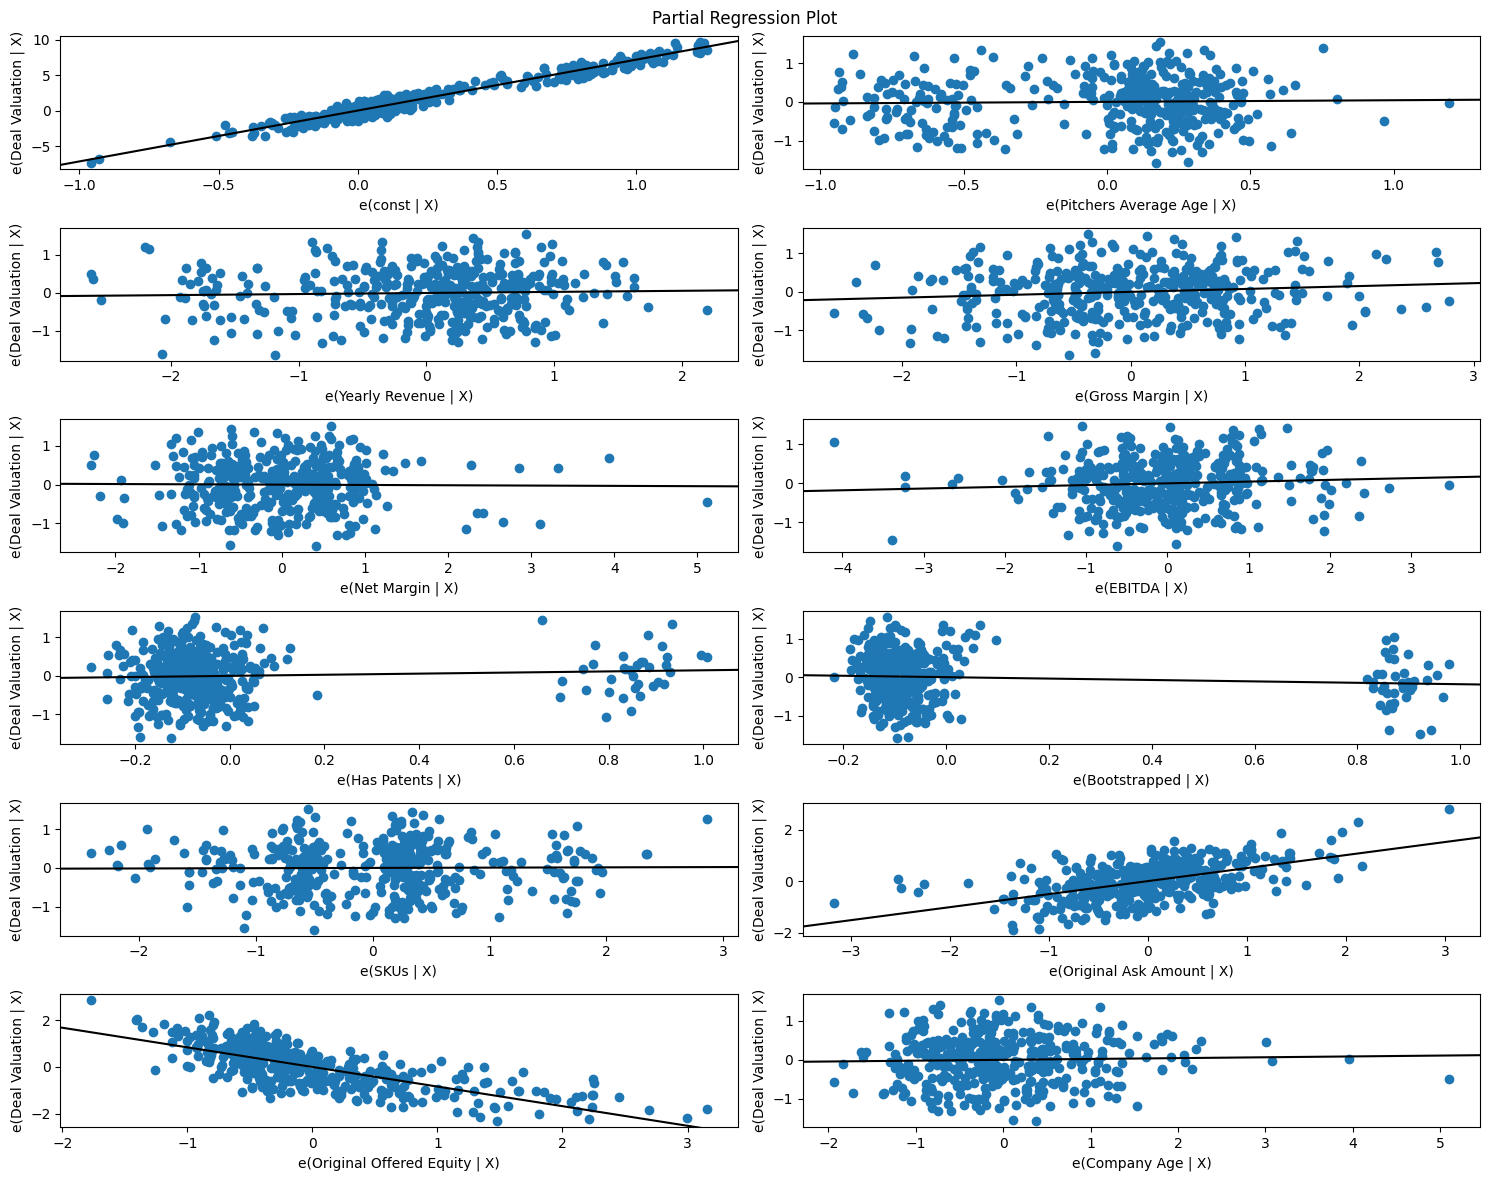

In [14]:


# Set up the figure size to be large enough to hold all the subplots
fig = plt.figure(figsize=(15, 12))

# plot_partregress_grid automatically generates the Added Variable Plots for every feature in your model
sm.graphics.plot_partregress_grid(model, fig=fig)

plt.tight_layout()
plt.show()

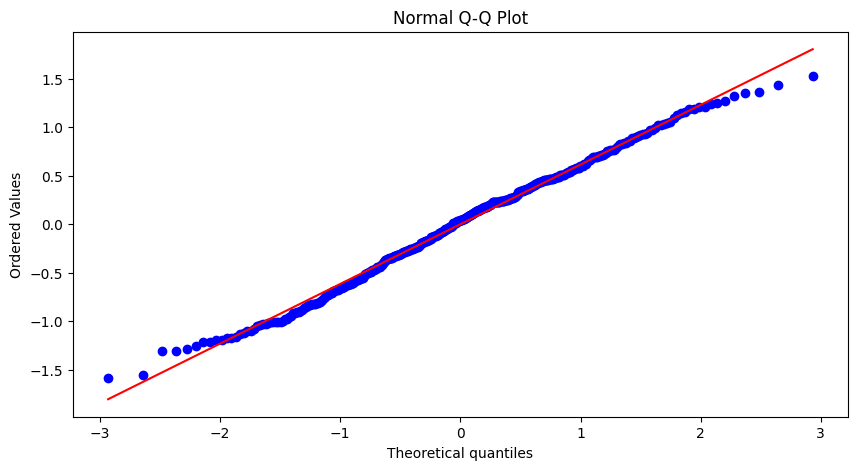

In [15]:
# B. QQ-Plot (Checking Normality of Errors)
plt.figure(figsize=(10, 5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot')
plt.show()

finding the baseline(industry) for dummy multiple linear regresion 

In [16]:
industry_col = ['Agriculture', 'Animal/Pets', 'Beauty/Fashion', 'Business Services',
       'Children/Education', 'Electronics', 'Entertainment',
       'Fitness/Sports/Outdoors', 'Food And Beverage', 'Green/Cleantech',
       'Hardware', 'Lifestyle/Home', 'Liquor/Alcohol', 'Manufacturing',
       'Medical/Health', 'Others', 'Technology/Software',
       'Vehicles/Electrical Vehicles']

# Initialize an empty list to store the combined data
industry_stats = []

# Loop through each industry dummy column
for industry in industry_col:
    # Filter the data where the specific industry dummy is 1
    industry_data = data[data[industry] == 1.0]
    
    # Calculate the mean of 'Deal Valuation'
    avg_val = industry_data['Deal Valuation'].mean()
    
    # Count the number of startups in this industry
    count = data[industry].sum()
    
    # Append the combined metrics as a row to our list
    industry_stats.append({
        'Industry': industry, 
        'Average Deal Valuation': avg_val, 
        'Number of Deals': count
    })

# Convert the list of dictionaries into a pandas DataFrame
avg_val_df = pd.DataFrame(industry_stats)

# Sort the values primarily by the highest Number of Deals
# (This puts the most statistically stable candidates at the top)
avg_val_df = avg_val_df.sort_values(by='Number of Deals', ascending=False).reset_index(drop=True)

# Display the results
print(avg_val_df)

                        Industry  Average Deal Valuation  Number of Deals
0              Food And Beverage                6.946072             95.0
1                 Beauty/Fashion                7.205244             86.0
2            Technology/Software                7.474295             48.0
3                 Medical/Health                7.582255             45.0
4                  Manufacturing                6.977471             24.0
5                 Lifestyle/Home                7.385829             20.0
6              Business Services                7.464603             18.0
7             Children/Education                7.050918             18.0
8                         Others                6.985851             17.0
9        Fitness/Sports/Outdoors                7.520686             16.0
10  Vehicles/Electrical Vehicles                6.585326              9.0
11               Green/Cleantech                6.490414              8.0
12                   Animal/Pets      

In [17]:
df.columns

Index(['Agriculture', 'Animal/Pets', 'Beauty/Fashion', 'Business Services',
       'Children/Education', 'Electronics', 'Entertainment',
       'Fitness/Sports/Outdoors', 'Food And Beverage', 'Green/Cleantech',
       'Hardware', 'Lifestyle/Home', 'Liquor/Alcohol', 'Manufacturing',
       'Medical/Health', 'Others', 'Technology/Software',
       'Vehicles/Electrical Vehicles', 'Pitchers Average Age',
       'Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Original Ask Amount',
       'Original Offered Equity', 'Deal Valuation', 'Company Age'],
      dtype='object')

In [18]:

Y = df['Deal Valuation'] 

X_features = df[['Agriculture', 'Animal/Pets', 'Beauty/Fashion', 'Business Services',
       'Children/Education', 'Electronics', 'Entertainment',
       'Fitness/Sports/Outdoors', 'Food And Beverage', 'Green/Cleantech',
       'Lifestyle/Home', 'Liquor/Alcohol', 'Manufacturing',
       'Medical/Health', 'Others', 'Technology/Software',
       'Vehicles/Electrical Vehicles', 'Pitchers Average Age',
       'Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Original Ask Amount',
       'Original Offered Equity', 'Company Age']]

X_train = X_features.astype(float)
Y_train = Y.astype(float)

X_train_sm = sm.add_constant(X_train)

model_1 = sm.OLS(Y_train, X_train_sm).fit()

display(model_1.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Deal Valuation   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     41.37
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.71e-96
Time:                        15:30:44   Log-Likelihood:                -376.17
No. Observations:                 412   AIC:                             808.3
Df Residuals:                     384   BIC:                             920.9
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            6.7819      0.078     86.608      0.000       6.628       6.936
Agriculture                      0.1837      0.330      0.557      0.578      -0.465       0.832
Animal/Pets                      0.6095      0.317      1.920      0.056      -0.015       1.234
Beauty/Fashion                   0.3317      0.097      3.422      0.001       0.141       0.522
Business Services                0.2712      0.251      1.082      0.280      -0.222       0.764
Children/Education               0.5925      0.155      3.813      0.000       0.287       0.898
Electronics                     -0.2536      0.473     -0.536      0.592      -1.184       0.676
Entertainment                    0.7649      0.360      2.126      0.034       0.057       1.472
Fitness/Sports/Outdoors          0.4695      0.267      1.756      0.080      -0.056       0.995
Food And Beverage                0.2974      0.127      2.344      0.020       0.048       0.547
Green/Cleantech                  0.6102      0.344      1.773      0.077      -0.066       1.287
Lifestyle/Home                   0.4162      0.214      1.948      0.052      -0.004       0.836
Liquor/Alcohol                   0.4044      0.356      1.137      0.256      -0.295       1.103
Manufacturing                    0.3719      0.204      1.827      0.068      -0.028       0.772
Medical/Health                   0.2113      0.174      1.216      0.225      -0.130       0.553
Others                           0.5889      0.217      2.711      0.007       0.162       1.016
Technology/Software              0.6959      0.202      3.450      0.001       0.299       1.093
Vehicles/Electrical Vehicles     0.2163      0.291      0.744      0.457      -0.355       0.788
Pitchers Average Age             0.0396      0.080      0.496      0.620      -0.117       0.196
Yearly Revenue                   0.0442      0.041      1.067      0.287      -0.037       0.126
Gross Margin                     0.1352      0.064      2.119      0.035       0.010       0.261
Net Margin                      -0.0384      0.052     -0.739      0.460      -0.141       0.064
EBITDA                          -0.0143      0.057     -0.250      0.803      -0.127       0.098
Has Patents                      0.1615      0.121      1.334      0.183      -0.077       0.400
Bootstrapped                    -0.1764      0.109     -1.614      0.107      -0.391       0.038
SKUs                            -0.0457      0.104     -0.440      0.660      -0.250       0.158
Original Ask Amount              0.5111      0.042     12.237      0.000       0.429       0.593
Original Offered Equity         -0.8237      0.041    -20.169      0.000      -0.904      -0.743
Company Age                      0.0148      0.037      0.401      0.689    

In [19]:

Y = df['Deal Valuation'] 

X_features = df[['Agriculture', 'Animal/Pets', 'Beauty/Fashion', 'Business Services',
       'Children/Education', 'Electronics', 'Entertainment',
       'Fitness/Sports/Outdoors', 'Hardware', 'Green/Cleantech',
       'Lifestyle/Home', 'Liquor/Alcohol', 'Manufacturing',
       'Medical/Health', 'Others', 'Technology/Software',
       'Vehicles/Electrical Vehicles', 'Pitchers Average Age',
       'Yearly Revenue', 'Gross Margin', 'Net Margin', 'EBITDA', 'Has Patents',
       'Bootstrapped', 'SKUs', 'Original Ask Amount',
       'Original Offered Equity', 'Company Age']]

X_train = X_features.astype(float)
Y_train = Y.astype(float)

X_train_sm = sm.add_constant(X_train)

model_2 = sm.OLS(Y_train, X_train_sm).fit()

display(model_2.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Deal Valuation   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     41.37
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.71e-96
Time:                        15:30:44   Log-Likelihood:                -376.17
No. Observations:                 412   AIC:                             808.3
Df Residuals:                     384   BIC:                             920.9
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            7.0793      0.126     56.024      0.000       6.831       7.328
Agriculture                     -0.1136      0.372     -0.305      0.760      -0.845       0.618
Animal/Pets                      0.3121      0.375      0.832      0.406      -0.425       1.050
Beauty/Fashion                   0.0343      0.148      0.233      0.816      -0.256       0.324
Business Services               -0.0261      0.207     -0.126      0.900      -0.434       0.382
Children/Education               0.2951      0.197      1.497      0.135      -0.092       0.683
Electronics                     -0.5510      0.491     -1.123      0.262      -1.515       0.413
Entertainment                    0.4675      0.390      1.197      0.232      -0.300       1.235
Fitness/Sports/Outdoors          0.1721      0.338      0.509      0.611      -0.492       0.837
Hardware                     -2.118e-16   3.45e-16     -0.615      0.539   -8.89e-16    4.66e-16
Green/Cleantech                  0.3129      0.327      0.957      0.339      -0.330       0.955
Lifestyle/Home                   0.1188      0.269      0.442      0.659      -0.410       0.648
Liquor/Alcohol                   0.1070      0.381      0.281      0.779      -0.643       0.857
Manufacturing                    0.0745      0.276      0.270      0.788      -0.469       0.618
Medical/Health                  -0.0861      0.146     -0.589      0.556      -0.374       0.201
Others                           0.2915      0.267      1.090      0.276      -0.234       0.817
Technology/Software              0.3986      0.275      1.450      0.148      -0.142       0.939
Vehicles/Electrical Vehicles    -0.0810      0.319     -0.254      0.799      -0.707       0.545
Pitchers Average Age             0.0396      0.080      0.496      0.620      -0.117       0.196
Yearly Revenue                   0.0442      0.041      1.067      0.287      -0.037       0.126
Gross Margin                     0.1352      0.064      2.119      0.035       0.010       0.261
Net Margin                      -0.0384      0.052     -0.739      0.460      -0.141       0.064
EBITDA                          -0.0143      0.057     -0.250      0.803      -0.127       0.098
Has Patents                      0.1615      0.121      1.334      0.183      -0.077       0.400
Bootstrapped                    -0.1764      0.109     -1.614      0.107      -0.391       0.038
SKUs                            -0.0457      0.104     -0.440      0.660      -0.250       0.158
Original Ask Amount              0.5111      0.042     12.237      0.000       0.429       0.593
Original Offered Equity         -0.8237      0.041    -20.169      0.000      -0.904      -0.743
Company Age                      0.0148      0.037      0.401      0.689    

In [20]:
model_2.params

const                           7.079281e+00
Agriculture                    -1.136203e-01
Animal/Pets                     3.120854e-01
Beauty/Fashion                  3.433603e-02
Business Services              -2.612628e-02
Children/Education              2.950946e-01
Electronics                    -5.509946e-01
Entertainment                   4.675263e-01
Fitness/Sports/Outdoors         1.721255e-01
Hardware                       -2.118376e-16
Green/Cleantech                 3.128641e-01
Lifestyle/Home                  1.188292e-01
Liquor/Alcohol                  1.070113e-01
Manufacturing                   7.454170e-02
Medical/Health                 -8.607075e-02
Others                          2.914929e-01
Technology/Software             3.985737e-01
Vehicles/Electrical Vehicles   -8.103635e-02
Pitchers Average Age            3.957379e-02
Yearly Revenue                  4.423182e-02
Gross Margin                    1.351662e-01
Net Margin                     -3.843830e-02
EBITDA    

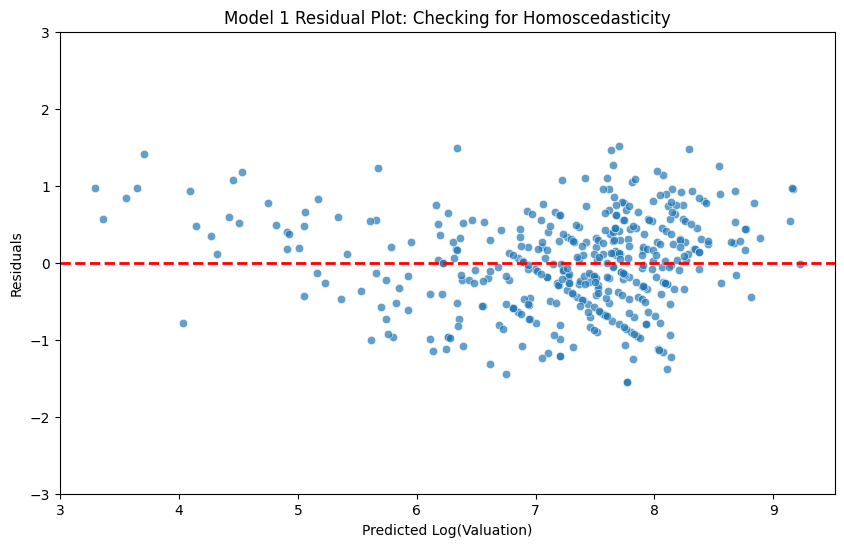

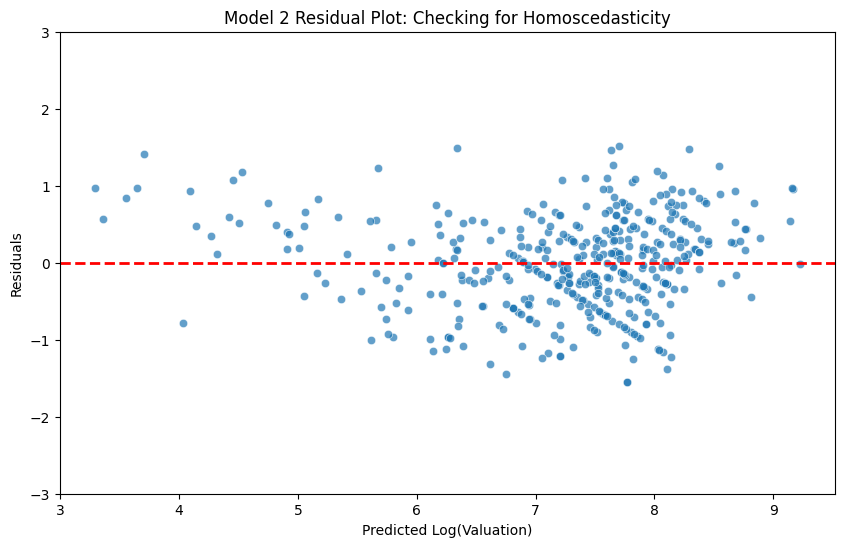

In [21]:

# ---------------- Model 1 Plot ----------------
residuals = model_1.resid
fitted = model_1.fittedvalues

plt.figure(figsize=(10, 6))
# 1. Draw the plot first
sns.scatterplot(x=fitted, y=residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# 2. Set the limits AFTER drawing the plot
plt.ylim(-3, 3)

plt.xlabel('Predicted Log(Valuation)')
plt.ylabel('Residuals')
plt.title('Model 1 Residual Plot: Checking for Homoscedasticity')
plt.show()


# ---------------- Model 2 Plot ----------------
residuals = model_2.resid
fitted = model_2.fittedvalues

plt.figure(figsize=(10, 6))
# 1. Draw the plot first
sns.scatterplot(x=fitted, y=residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# 2. Set the limits AFTER drawing the plot
plt.ylim(-3, 3)

plt.xlabel('Predicted Log(Valuation)')
plt.ylabel('Residuals')
plt.title('Model 2 Residual Plot: Checking for Homoscedasticity')
plt.show()

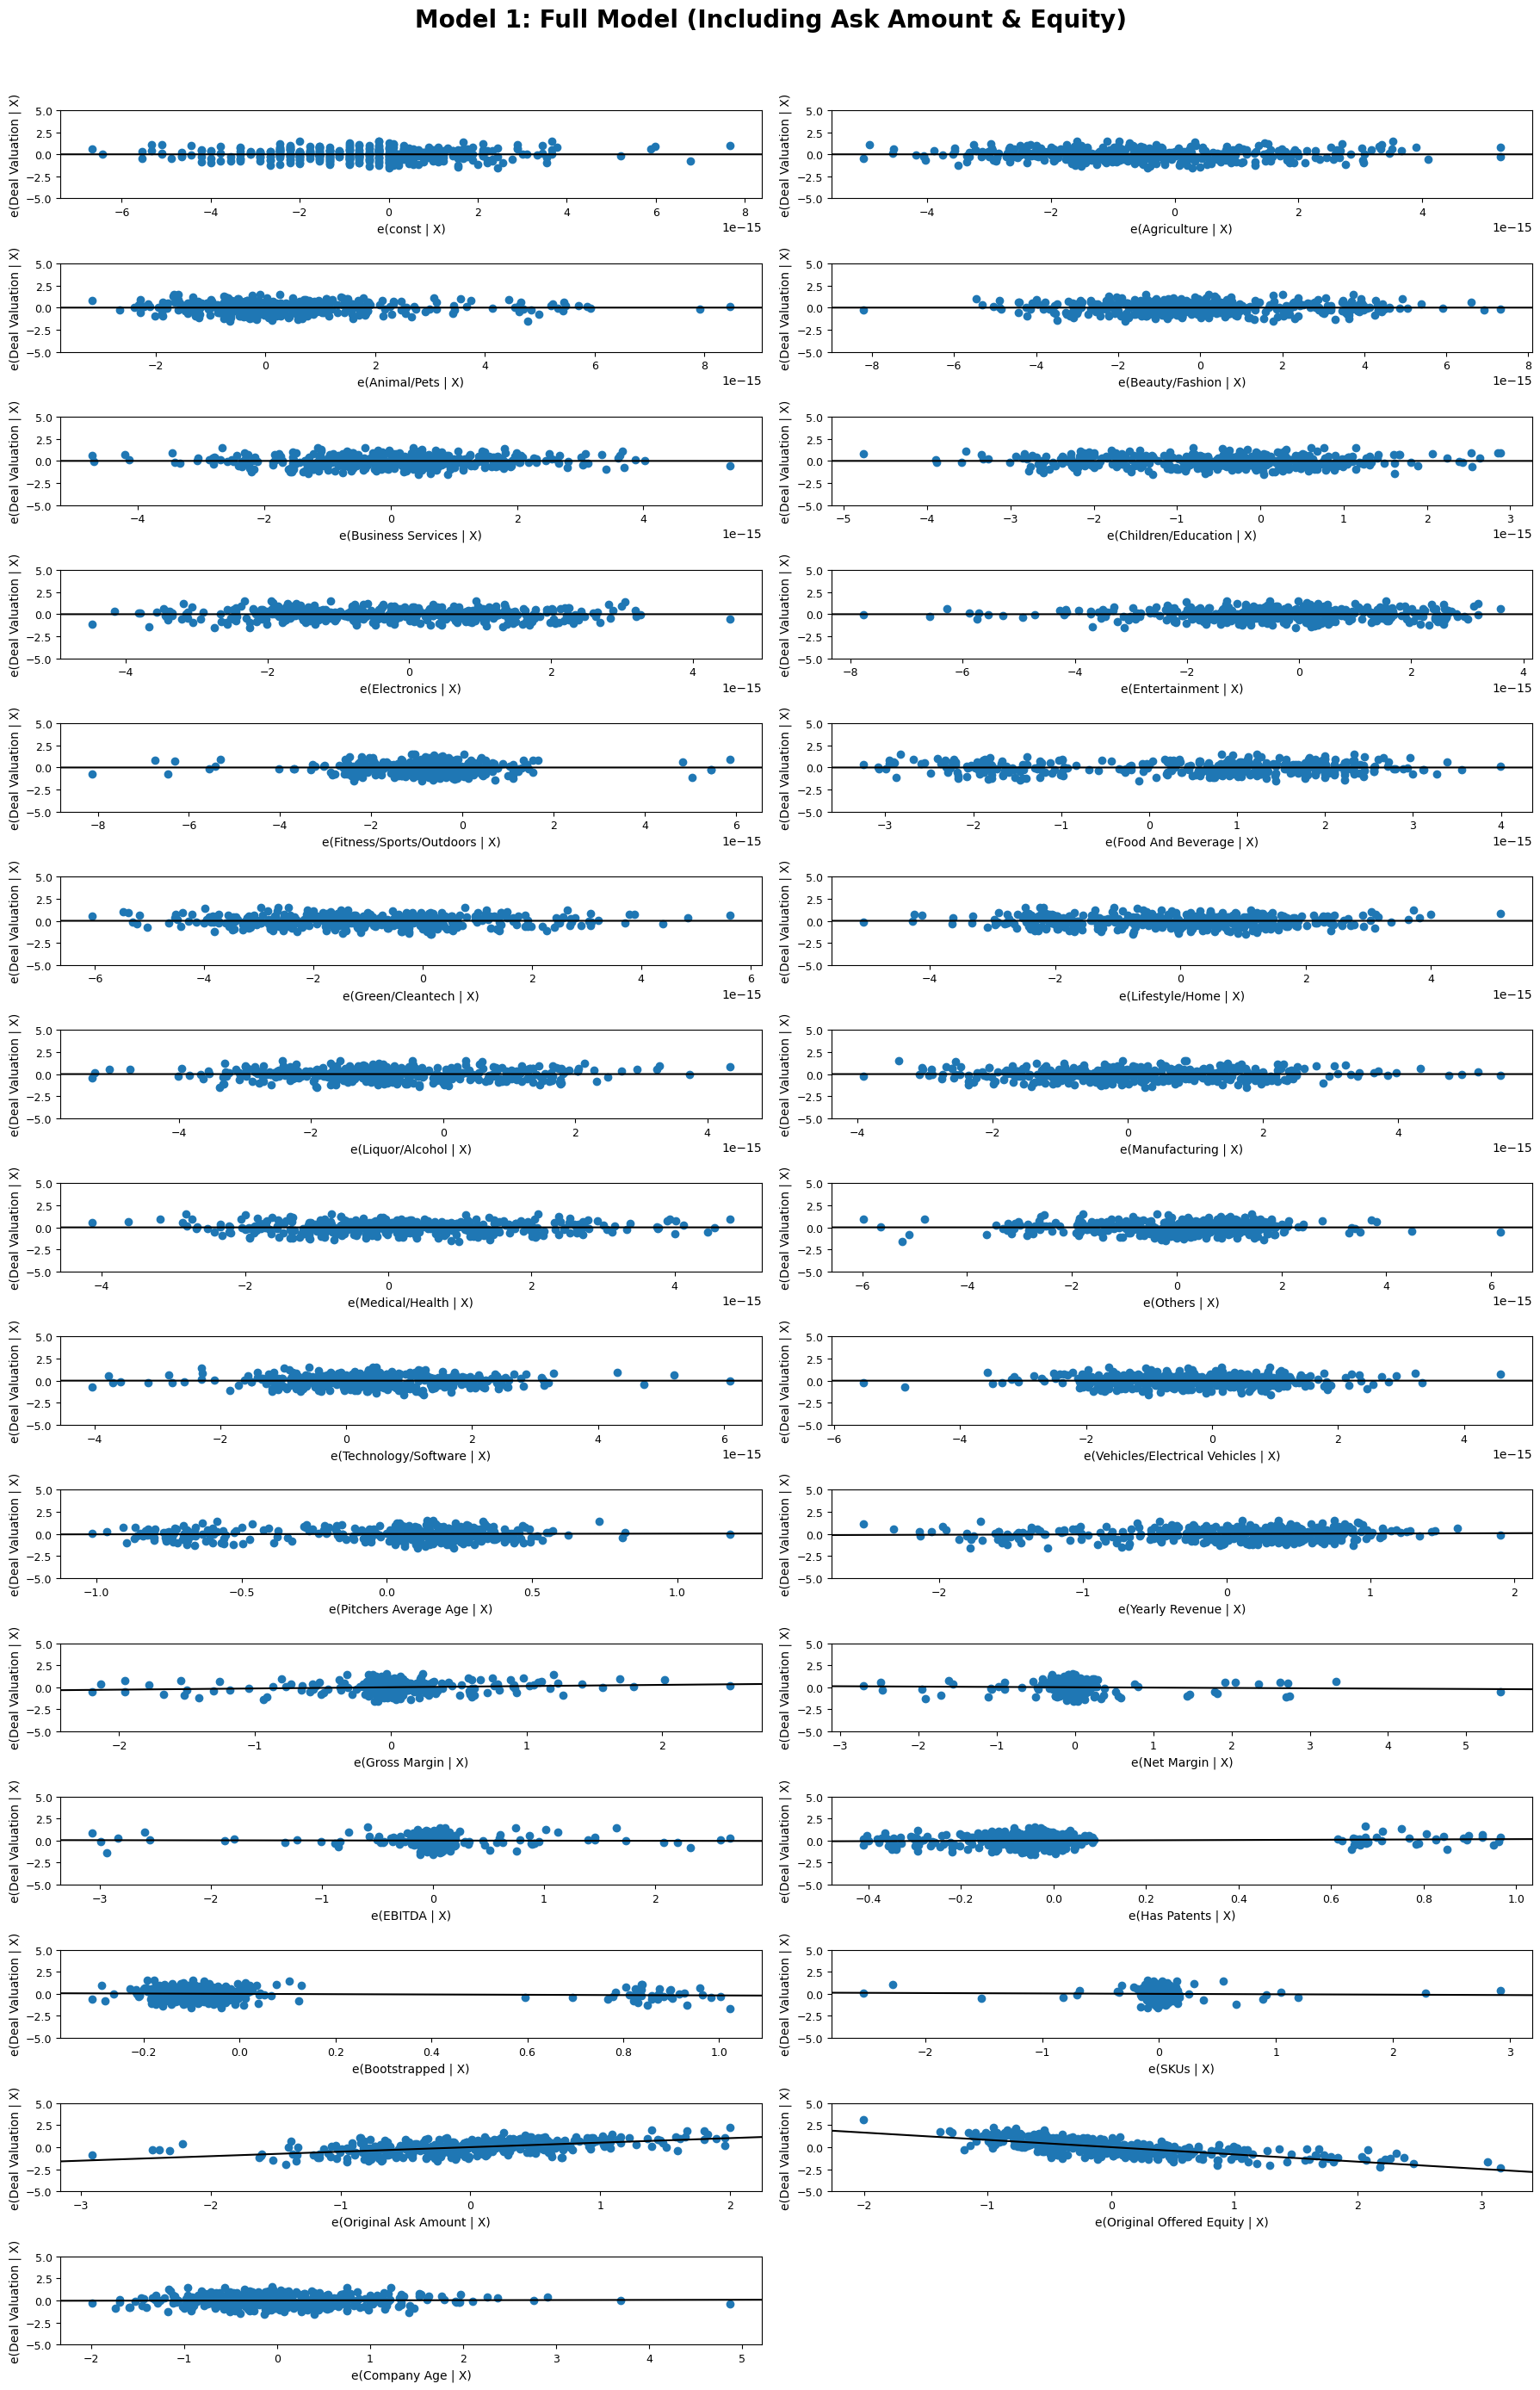

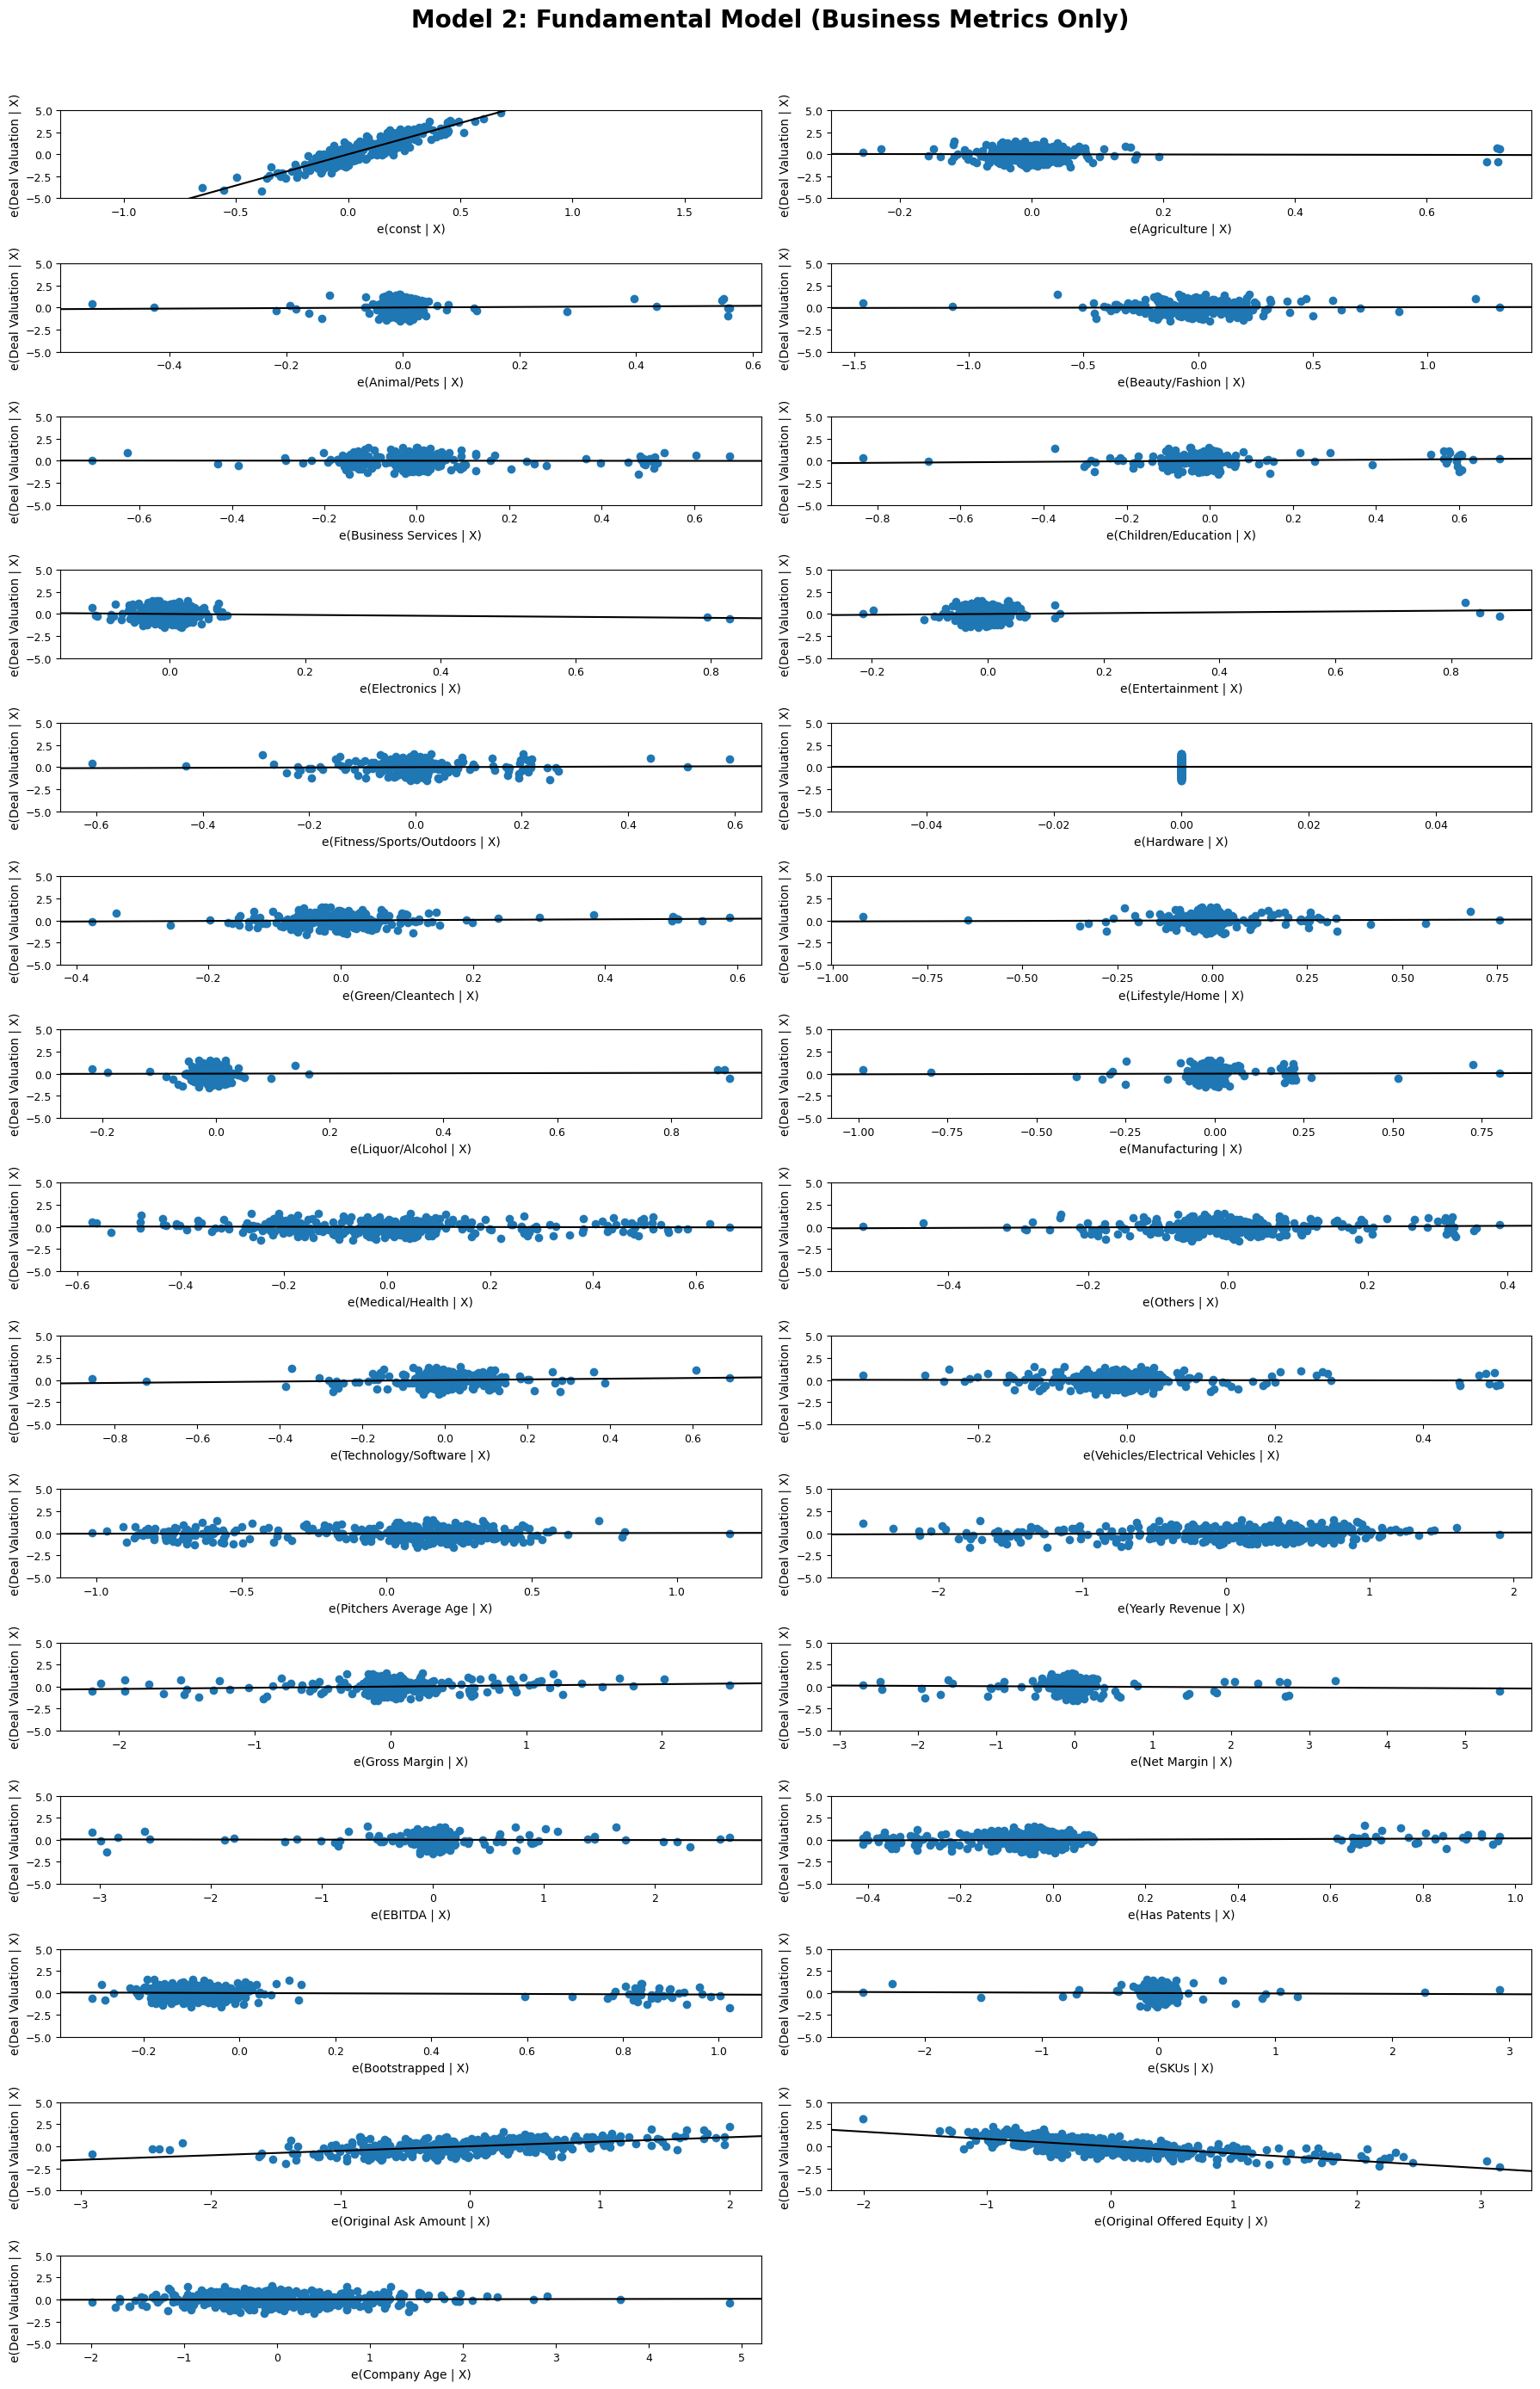

In [22]:
y_min = -5
y_max = 5

# ==========================================
# PART 1: Partial Regression Plots for MODEL 1
# ==========================================
# FIX 1: Massively increase figure height (from 12 to 24 or 30) 
# to give 26 subplots room to render the y-axis properly.
fig1 = plt.figure(figsize=(18, 28)) 

sm.graphics.plot_partregress_grid(model_1, fig=fig1)

for ax in fig1.axes:
    ax.set_ylim(y_min, y_max)
    # FIX 2: Slightly reduce tick label size to prevent them from overlapping
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle("Model 1: Full Model (Including Ask Amount & Equity)", fontsize=20, fontweight='bold', y=0.99)

# FIX 3: Use specific padding within tight_layout to separate the subplots
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.0, w_pad=1.5)
plt.show()


# ==========================================
# PART 2: Partial Regression Plots for MODEL 2
# ==========================================
fig2 = plt.figure(figsize=(18, 28))

sm.graphics.plot_partregress_grid(model_2, fig=fig2)

for ax in fig2.axes:
    ax.set_ylim(y_min, y_max)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle("Model 2: Fundamental Model (Business Metrics Only)", fontsize=20, fontweight='bold', y=0.99)

plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.0, w_pad=1.5)
plt.show()

In [23]:
# This saves the model to a file in your current directory
model_1.save("models/valuation_model_1.pkl")